In [1]:
#import libraries and data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/adult_dataset.csv")
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [3]:
df['native-country'].value_counts()
df['native-country'] = df['native-country'].replace('?',np.nan)
df['workclass'] = df['workclass'].replace('?',np.nan)
df['occupation'] = df['occupation'].replace('?',np.nan)


In [4]:
#find missing values
df.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [5]:
#fill missing values
df["age"] = df["age"].fillna(df["age"].median())
df["workclass"] = df["workclass"].fillna(df["workclass"].mode()[0])
df["occupation"] = df["occupation"].fillna(df["occupation"].mode()[0])
df["age"] = df["age"].fillna(df["age"].median())
df["hours-per-week"] = df["hours-per-week"].fillna(df["hours-per-week"].median())
df["native-country"] = df["native-country"].fillna(df["native-country"].mode()[0])

In [6]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
#check for duplicates
df.duplicated().sum()

np.int64(22)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48820 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48820 non-null  float64
 1   workclass       48820 non-null  object 
 2   fnlwgt          48820 non-null  int64  
 3   education       48820 non-null  object 
 4   education-num   48820 non-null  int64  
 5   marital-status  48820 non-null  object 
 6   occupation      48820 non-null  object 
 7   relationship    48820 non-null  object 
 8   race            48820 non-null  object 
 9   sex             48820 non-null  object 
 10  capital-gain    48820 non-null  int64  
 11  capital-loss    48820 non-null  int64  
 12  hours-per-week  48820 non-null  float64
 13  native-country  48820 non-null  object 
 14  income          48820 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 6.0+ MB


In [11]:
df.describe()



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48820.000000,4.882000e+04,48820.000000,48820.000000,48820.000000,48820.000000
mean,38.597890,1.896605e+05,10.078554,1079.553892,87.541745,40.428165
std,13.603254,1.056057e+05,2.570387,7453.662758,403.091066,12.326679
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175535e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781350e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376210e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [12]:
df["income"].value_counts()

,count
income,
<=50K,24705
<=50K.,12430
>50K,7839
>50K.,3846


In [13]:
df["income"] = df["income"].str.replace(".", "", regex=False)
df["income"].value_counts()

,count
income,
<=50K,37135
>50K,11685


In [14]:
df.income = df.income.replace('<=50K', 0)
df.income = df.income.replace('>50K', 1)

/tmp/ipykernel_20826/3152918573.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.income = df.income.replace('>50K', 1)


In [15]:
df.corr(numeric_only=True)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
age,1.000000,-0.073929,0.029372,0.073558,0.056221,0.098995,0.219286
fnlwgt,-0.073929,1.000000,-0.038706,-0.003702,-0.004360,-0.011057,-0.006336
education-num,0.029372,-0.038706,1.000000,0.125178,0.080970,0.136146,0.332727
capital-gain,0.073558,-0.003702,0.125178,1.000000,-0.031455,0.079856,0.223020
capital-loss,0.056221,-0.004360,0.080970,-0.031455,1.000000,0.050916,0.147541
hours-per-week,0.098995,-0.011057,0.136146,0.079856,0.050916,1.000000,0.215358
income,0.219286,-0.006336,0.332727,0.223020,0.147541,0.215358,1.000000


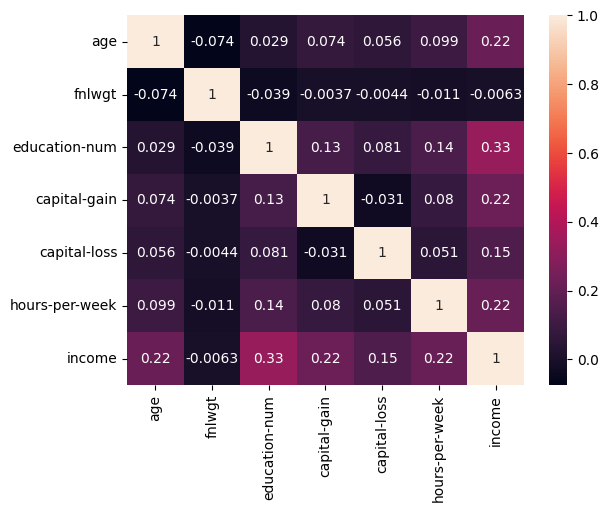

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [17]:
df.duplicated().sum()

np.int64(22)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.groupby("income")["capital-gain"].mean()

,capital-gain
income,
0,147.160816
1,4044.315812


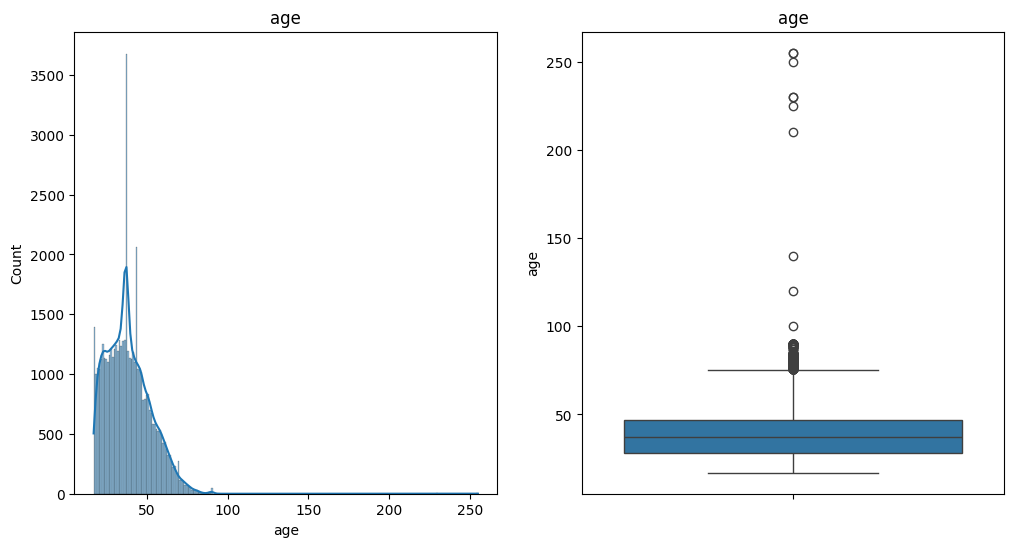

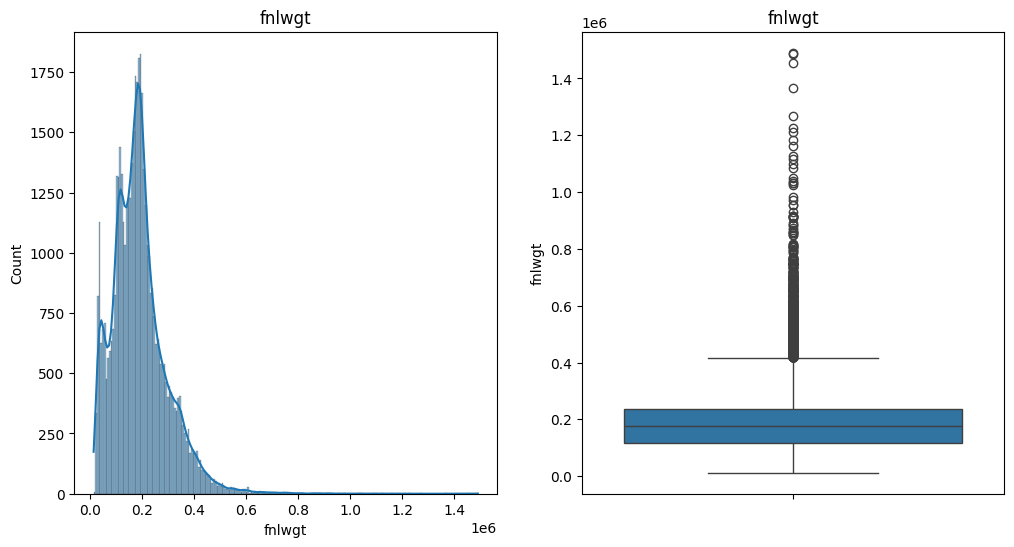

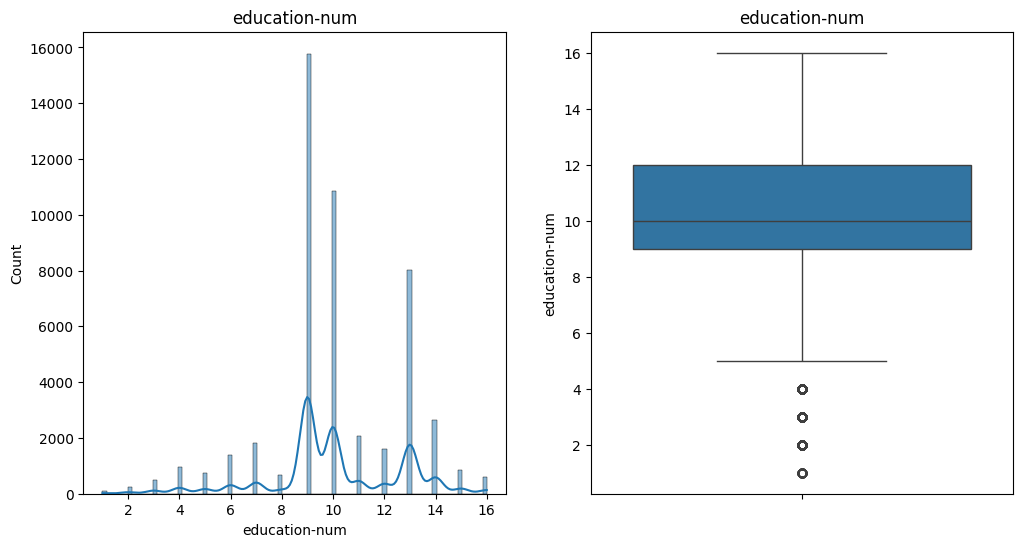

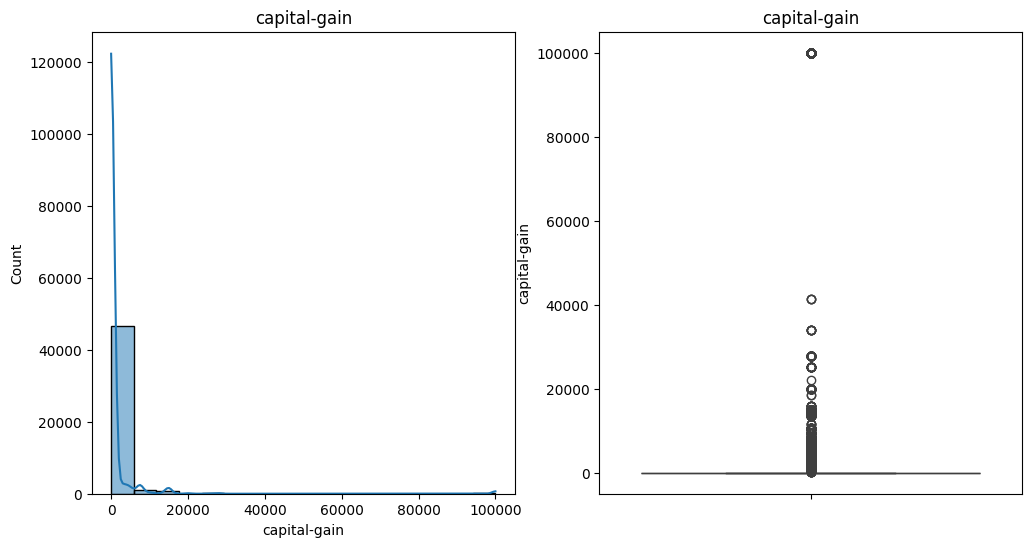

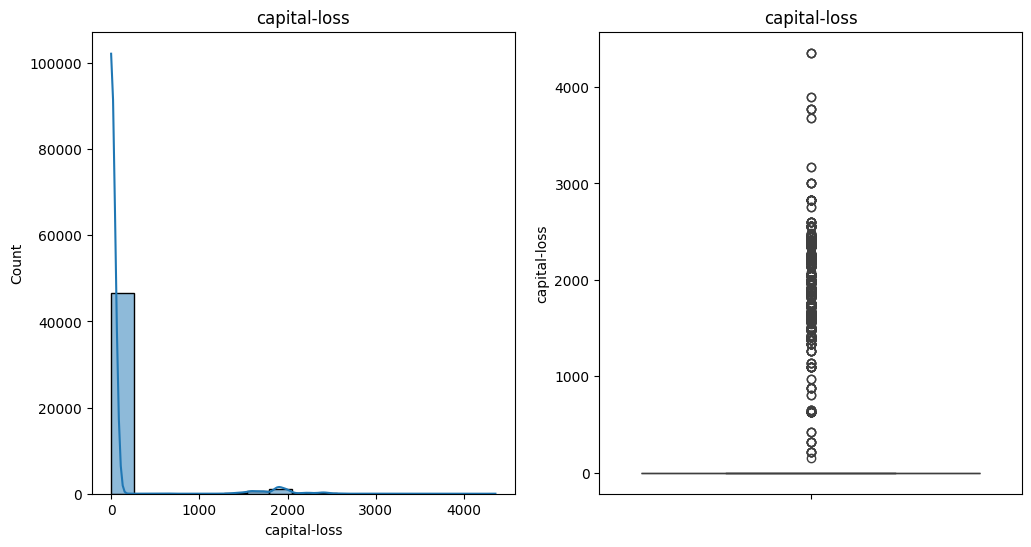

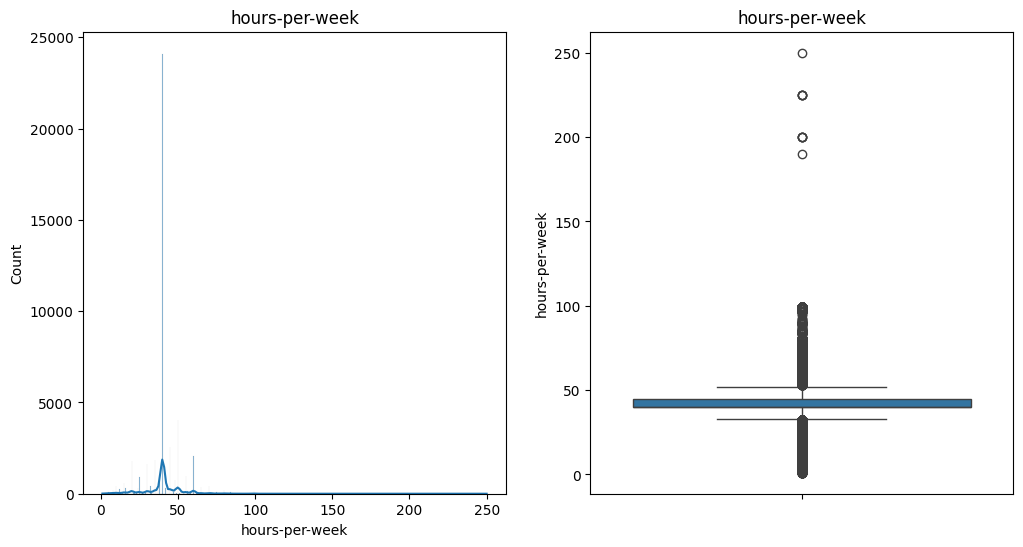

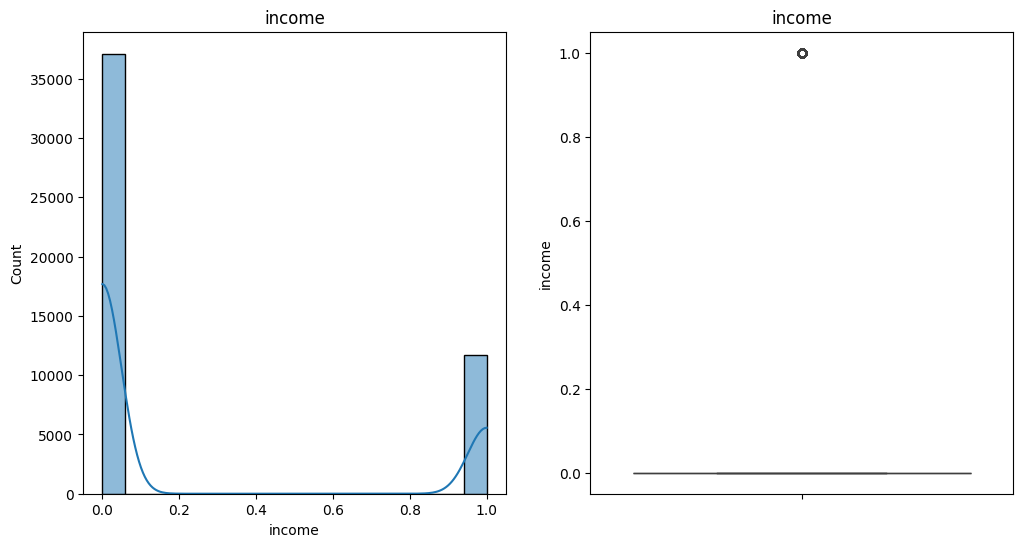

In [21]:
#draw box plot to find outliers
for col in df.select_dtypes("number"):
    plt.figure(figsize=(12, 6))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.subplot(1,2,2)
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [22]:
df.groupby("income")["capital-gain"].mean()

,capital-gain
income,
0,147.160816
1,4044.315812


In [23]:
#find outliers
outliers_cols = ["age", "hours-per-week"] # removing "capital-gain" from outlier checking
for col in outliers_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", outliers.shape)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
df

age : (363, 15)
hours-per-week : (12592, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,0
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,0
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,0
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,0
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33.0,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40.0,United-States,0
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,0
48838,64.0,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40.0,United-States,0
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,0


In [24]:
df.shape

(35843, 15)

##EDA

In [25]:
df["race"].groupby(df["income"]).value_counts()

income  race              
0       White                 22198
        Black                  3209
        Asian-Pac-Islander      807
        Amer-Indian-Eskimo      313
        Other                   265
1       White                  8164
        Black                   471
        Asian-Pac-Islander      332
        Amer-Indian-Eskimo       45
        Other                    39
Name: count, dtype: int64

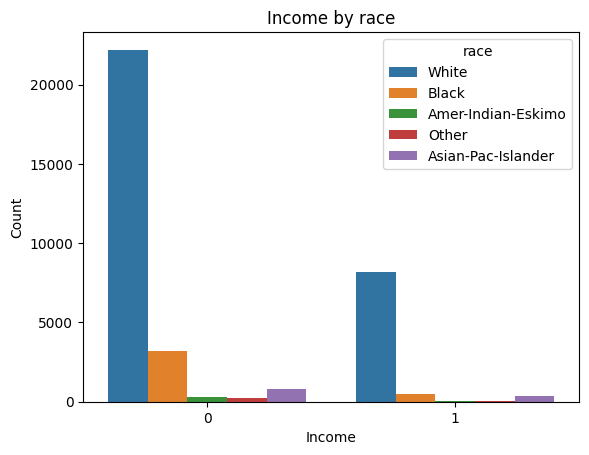

In [26]:
sns.countplot(data=df, x="income", hue="race")

plt.title("Income by race")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Analysis: White people gets more income than other races.

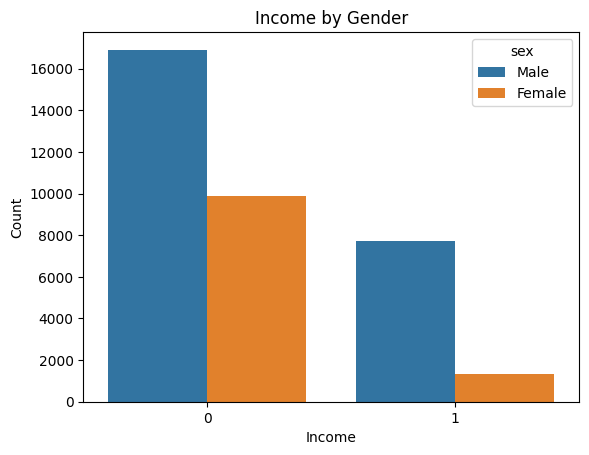

In [27]:
sns.countplot(data=df, x="income", hue="sex")

plt.title("Income by Gender")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Analysis: Male get more salary than female for both income range:

In [28]:
df["age"].groupby(df["income"]).value_counts()

income  age 
0       37.0    1985
        27.0     859
        25.0     857
        28.0     843
        23.0     840
                ... 
1       72.0       7
        21.0       5
        73.0       5
        19.0       1
        20.0       1
Name: count, Length: 116, dtype: int64

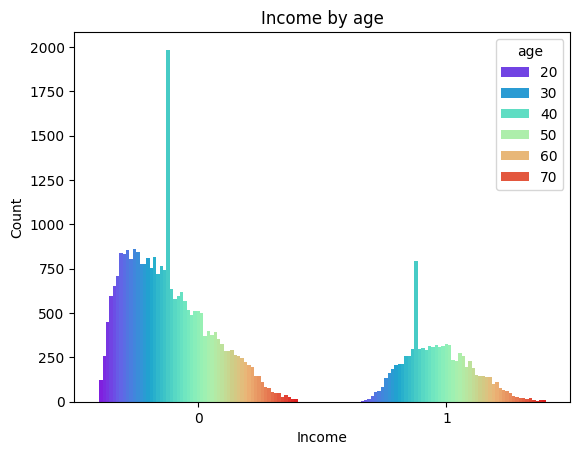

In [29]:
sns.countplot(data=df, x="income", hue="age",palette="rainbow")

plt.title("Income by age")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Analysis: People with age <=40 has higher income

In [30]:
df["capital-gain"].groupby(df["income"]).value_counts()

income  capital-gain
0       0               25678
        5013               94
        3325               72
        2174               66
        4650               53
                        ...  
1       7896                3
        11678               3
        6097                2
        6612                1
        25124               1
Name: count, Length: 115, dtype: int64

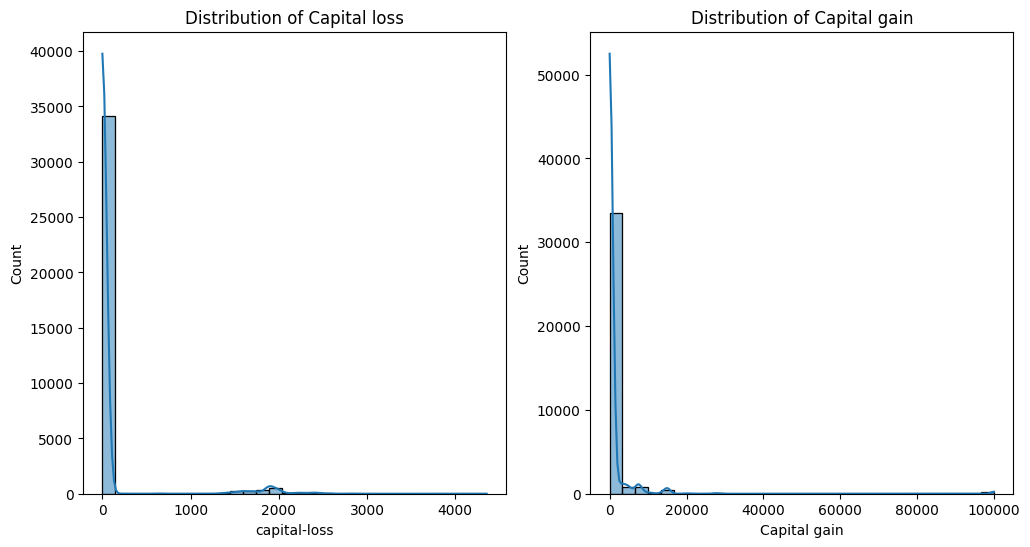

In [31]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Distribution of Capital loss")

sns.histplot(df["capital-loss"], bins=30, kde=True)
plt.subplot(1,2,2)
plt.title("Distribution of Capital gain")

sns.histplot(df["capital-gain"], bins=30, kde=True)

plt.xlabel("Capital gain")
plt.ylabel("Count")
plt.show()

In capital loss, and capital gain

Many values are 0

Few very high values

Strong right/positive skewness

In [32]:
print("Capital Gain Skewness:", df["capital-gain"].skew())
print("Capital Loss Skewness:", df["capital-loss"].skew())

Capital Gain Skewness: 12.876475758986484
Capital Loss Skewness: 4.510659546927828


In [33]:
#applying log transformation to gain and loss
df["capital-gain"] = np.log1p(df["capital-gain"])
df["capital-loss"] = np.log1p(df["capital-loss"])

In [34]:
# df.drop("fnlwgt", axis=1, inplace=True)

In [35]:
#encode all cat columns except income, encoding native country as well as there is not target
cat_columns = df.select_dtypes("object").columns.tolist()
print(cat_columns)
# cat_columns = cat_columns[:-1]
cat_columns

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [36]:
from sklearn.preprocessing import LabelEncoder
df_encoded= df.copy()
le = LabelEncoder()
for col in cat_columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

df_encoded

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6,77516,9,13,4,0,1,4,1,7.684784,0.0,40.0,38,0
2,38.0,3,215646,11,9,0,5,1,4,1,0.000000,0.0,40.0,38,0
3,53.0,3,234721,1,7,2,5,0,2,1,0.000000,0.0,40.0,38,0
4,28.0,3,338409,9,13,2,9,5,2,0,0.000000,0.0,40.0,4,0
5,37.0,3,284582,12,14,2,3,5,4,0,0.000000,0.0,40.0,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33.0,3,245211,9,13,4,9,3,4,1,0.000000,0.0,40.0,38,0
48837,39.0,3,215419,9,13,0,9,1,4,0,0.000000,0.0,36.0,38,0
48838,64.0,3,321403,11,9,6,9,2,2,1,0.000000,0.0,40.0,38,0
48839,38.0,3,374983,9,13,2,9,0,4,1,0.000000,0.0,50.0,38,0


In [37]:
#scale values
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = df_encoded.drop("income", axis=1)
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.37931034, 0.85714286, 0.04317057, ..., 0.        , 0.36842105,
        0.95      ],
       [0.36206897, 0.42857143, 0.13671459, ..., 0.        , 0.36842105,
        0.95      ],
       [0.62068966, 0.42857143, 0.14963251, ..., 0.        , 0.36842105,
        0.95      ],
       ...,
       [0.81034483, 0.42857143, 0.20833505, ..., 0.        , 0.36842105,
        0.95      ],
       [0.36206897, 0.42857143, 0.24462036, ..., 0.        , 0.89473684,
        0.95      ],
       [0.46551724, 0.42857143, 0.04748783, ..., 0.        , 0.36842105,
        0.95      ]])

##Clustering

In [38]:
#KMEans clustering


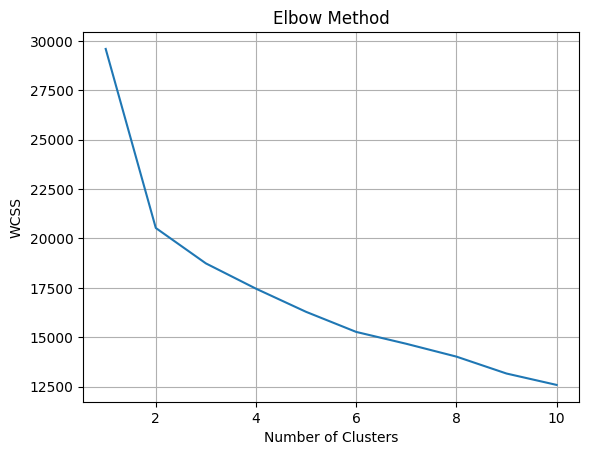

In [39]:
##find number of clusters using elbow method
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init="k-means++", n_init=15, max_iter=300)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


In [40]:
X_scaled

array([[0.37931034, 0.85714286, 0.04317057, ..., 0.        , 0.36842105,
        0.95      ],
       [0.36206897, 0.42857143, 0.13671459, ..., 0.        , 0.36842105,
        0.95      ],
       [0.62068966, 0.42857143, 0.14963251, ..., 0.        , 0.36842105,
        0.95      ],
       ...,
       [0.81034483, 0.42857143, 0.20833505, ..., 0.        , 0.36842105,
        0.95      ],
       [0.36206897, 0.42857143, 0.24462036, ..., 0.        , 0.89473684,
        0.95      ],
       [0.46551724, 0.42857143, 0.04748783, ..., 0.        , 0.36842105,
        0.95      ]])

In [41]:
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering  #knn, dt, rf
kmeans = KMeans(n_clusters=3,init="k-means++",n_init=15, max_iter=300)
labels  = kmeans.fit_predict(X_scaled)
df_clustered = X.copy()
df_clustered['KMeans_Labels'] = labels

df_clustered

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,KMeans_Labels
0,39.0,6,77516,9,13,4,0,1,4,1,7.684784,0.0,40.0,38,0
2,38.0,3,215646,11,9,0,5,1,4,1,0.000000,0.0,40.0,38,0
3,53.0,3,234721,1,7,2,5,0,2,1,0.000000,0.0,40.0,38,0
4,28.0,3,338409,9,13,2,9,5,2,0,0.000000,0.0,40.0,4,1
5,37.0,3,284582,12,14,2,3,5,4,0,0.000000,0.0,40.0,38,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33.0,3,245211,9,13,4,9,3,4,1,0.000000,0.0,40.0,38,2
48837,39.0,3,215419,9,13,0,9,1,4,0,0.000000,0.0,36.0,38,1
48838,64.0,3,321403,11,9,6,9,2,2,1,0.000000,0.0,40.0,38,2
48839,38.0,3,374983,9,13,2,9,0,4,1,0.000000,0.0,50.0,38,2


In [42]:
# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
km_silhouette = silhouette_score(X_scaled, labels)

print(km_silhouette)

0.18152034144965556


## Agglomerative Clustering


In [43]:
 #bottom up technique
# Example with 3 clusters
hc = AgglomerativeClustering(n_clusters=3,linkage="ward")

# Fit and predict clusters
labels = hc.fit_predict(X_scaled)
df_clustered['Agglomerative_Labels'] = labels
df_clustered.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,KMeans_Labels,Agglomerative_Labels
0,39.0,6,77516,9,13,4,0,1,4,1,7.684784,0.0,40.0,38,0,2
2,38.0,3,215646,11,9,0,5,1,4,1,0.000000,0.0,40.0,38,0,0
3,53.0,3,234721,1,7,2,5,0,2,1,0.000000,0.0,40.0,38,0,0
4,28.0,3,338409,9,13,2,9,5,2,0,0.000000,0.0,40.0,4,1,1
5,37.0,3,284582,12,14,2,3,5,4,0,0.000000,0.0,40.0,38,1,1


In [44]:
from sklearn.metrics import silhouette_score
labels = hc.labels_
agg_silhouette = silhouette_score(X_scaled, labels)

print(agg_silhouette)

0.2392518660480741


In [45]:
import numpy as np

print(np.isnan(X_scaled).sum())
print(np.isinf(X_scaled).sum())

0
0


##DBSCAN

In [46]:
# DBSCAN
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10)
labels = db.fit_predict(X_scaled)
df_clustered['DBSCAN_Labels'] = labels


In [47]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

dbscan_labels = df_clustered['DBSCAN_Labels']
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Silhouette score requires at least 2 clusters (and cannot treat everything as noise)
if n_clusters_db > 1:
    db_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
  db_silhouette = "N/A (Not enough distinct clusters found)"

In [48]:
print(f"K-Means Silhouette Score:         {km_silhouette:.4f}")
print(f"Agglomerative Silhouette Score:   {agg_silhouette:.4f}")
print(f"DBSCAN Silhouette Score:          {db_silhouette if isinstance(db_silhouette, str) else f'{db_silhouette:.4f}'}")

K-Means Silhouette Score:         0.1815
Agglomerative Silhouette Score:   0.2393
DBSCAN Silhouette Score:          0.1602


Agglomerative clustering performed better than K-Means and DBSCAN, indicating more clearly separated clusters. K-Means showed moderate performance, while DBSCAN was less effective because the dataset does not have strong density-based patterns and is sensitive to parameter selection.

In [49]:
analysis = df_clustered.groupby('Agglomerative_Labels').agg({
    'age': 'mean',
    'hours-per-week': 'mean',
    'capital-gain': 'mean',
    'education-num': 'mean'
})
print(analysis)

                            age  hours-per-week  capital-gain  education-num
Agglomerative_Labels                                                        
0                     38.708526       41.823081      0.000213       9.982931
1                     37.441284       40.468034      0.521586      10.167365
2                     43.297356       42.699610      8.870000      11.005202


In [50]:
analysis = df_clustered.groupby('KMeans_Labels').agg({
    'age': 'mean',
    'hours-per-week': 'mean',
    'capital-gain': 'mean',
    'education-num': 'mean'
})
print(analysis)

                     age  hours-per-week  capital-gain  education-num
KMeans_Labels                                                        
0              38.862969       41.779030      0.770892       9.534703
1              37.441284       40.468034      0.521586      10.167365
2              39.471729       42.057889      0.903930      10.737121


In [51]:
analysis = df_clustered.groupby('DBSCAN_Labels').agg({
    'age': 'mean',
    'hours-per-week': 'mean',
    'capital-gain': 'mean',
    'education-num': 'mean'
})
print(analysis)

                     age  hours-per-week  capital-gain  education-num
DBSCAN_Labels                                                        
-1             43.083969       42.776081      3.308888       9.227735
 0             43.311308       42.661238      8.885832      11.081899
 1             38.474020       41.769947      0.000000       9.945929
 2             37.180409       40.397527      0.439466      10.164812
 3             41.894868       42.540563      0.000000      11.009934
 4             38.996774       40.451613      0.000000      11.380645
 5             39.909091       39.045455      0.000000       1.000000
 6             42.200000       41.000000      0.000000      14.100000


Noises/outliers are,

In [52]:
df_clustered[df_clustered["DBSCAN_Labels"] == -1]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,KMeans_Labels,Agglomerative_Labels,DBSCAN_Labels
15,34.0,3,245487,5,4,2,13,0,0,1,0.000000,0.000000,45.0,25,2,0,-1
93,37.0,3,117747,11,9,2,11,5,1,0,0.000000,7.361375,35.0,38,1,1,-1
224,53.0,3,140359,13,1,4,9,1,4,0,0.000000,0.000000,35.0,38,1,1,-1
230,35.0,3,538583,1,7,5,13,1,2,1,8.209308,0.000000,40.0,38,2,2,-1
381,46.0,3,214955,4,3,0,9,1,4,0,0.000000,7.757906,45.0,38,1,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48641,29.0,3,97254,1,7,4,11,1,0,1,8.319230,0.000000,40.0,38,2,2,-1
48644,54.0,3,317733,10,16,6,12,4,4,1,0.000000,7.813187,40.0,38,2,0,-1
48731,48.0,3,236197,2,8,6,5,1,1,1,0.000000,0.000000,40.0,12,0,0,-1
48796,27.0,3,133770,9,13,4,9,1,1,1,7.697575,0.000000,52.0,29,2,2,-1


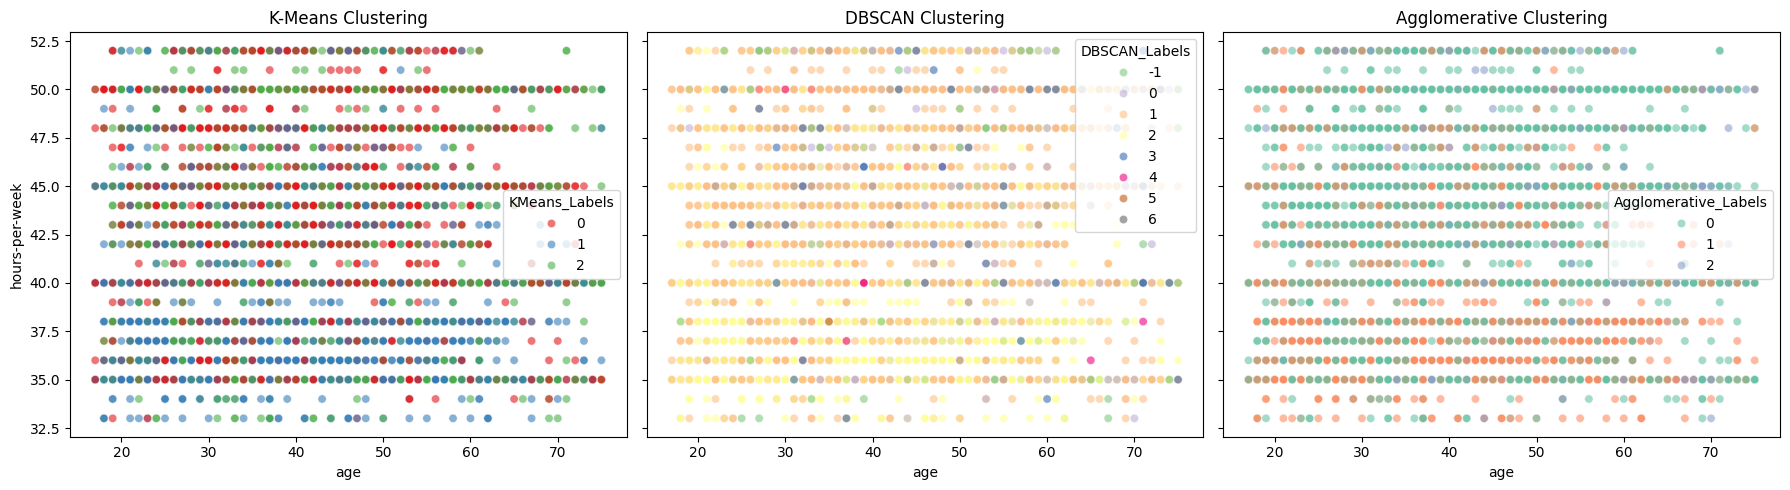

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot KMeans
sns.scatterplot(data=df_clustered, x='age', y='hours-per-week', hue='KMeans_Labels', palette='Set1', ax=axes[0], alpha=0.6)
axes[0].set_title('K-Means Clustering')

# Plot DBSCAN
sns.scatterplot(data=df_clustered, x='age', y='hours-per-week', hue='DBSCAN_Labels', palette='Accent', ax=axes[1], alpha=0.6)
axes[1].set_title('DBSCAN Clustering')

# Plot Agglomerative
sns.scatterplot(data=df_clustered, x='age', y='hours-per-week', hue='Agglomerative_Labels', palette='Set2', ax=axes[2], alpha=0.6)
axes[2].set_title('Agglomerative Clustering')

plt.tight_layout()
plt.show()

In [54]:
#Dimensionality Reduction using PCA (After Clustering)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize PCA to extract the top 2 principal components
pca = PCA(n_components=2)

# 2. Transform your scaled feature matrix (use the X_scaled from your pipeline)
X_pca = pca.fit_transform(X_scaled)

print("Final dimension after PCA:", X_pca.shape[1])

Final dimension after PCA: 2


In [55]:
import numpy as np
pca=PCA( )
pca.fit(X_scaled)
y=np.cumsum(pca.explained_variance_ratio_)
print(y)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance captured by first 2 components:")
print(pca.explained_variance_ratio_[:2].sum())


[0.32429132 0.43746762 0.53009035 0.6097089  0.67185367 0.7280778
 0.78400794 0.83156335 0.87521    0.91346967 0.94272539 0.96955592
 0.99389322 1.        ]
Explained variance ratio:
[0.32429132 0.1131763  0.09262273 0.07961855 0.06214477 0.05622413
 0.05593014 0.0475554  0.04364666 0.03825967 0.02925572 0.02683054
 0.0243373  0.00610678]
Total variance captured by first 2 components:
0.43746761502776205


The first two principal components capture approximately 43.75% of the total variance in the dataset. This means that almost half of the information from the original features can be visualized using only PC1 and PC2.

In [56]:
X_pca=pd.DataFrame(X_pca,columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
X_pca.sample(2)

,PC1,PC2
11524,0.333856,0.160821
9149,0.275145,0.234845


In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3)
X_pca["KNN-pca-cluster"]=kmeans.fit_predict(X_pca)
X_pca

kmeansscore = silhouette_score(X_pca,kmeans.labels_) #-1 to 1

In [58]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_pca)
X_pca["Agg-pca-cluster"]=agg_labels
X_pca

aggscore = silhouette_score(X_pca,agg_labels) #-1 to 1

In [59]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2, min_samples=10)
db_labels = db.fit_predict(X_pca)
X_pca["dbscan-pca-cluster"]=db_labels
X_pca
dbscore = silhouette_score(X_pca,agg_labels) #-1 to 1

In [60]:
print(f"After PCA K-Means Silhouette Score:         {kmeansscore:.4f}")
print(f"After PCA Agglomerative Silhouette Score:   {aggscore:.4f}")
print(f"After PCA DBSCAN Silhouette Score:          {dbscore:.4f}")

After PCA K-Means Silhouette Score:         0.8019
After PCA Agglomerative Silhouette Score:   0.8462
After PCA DBSCAN Silhouette Score:          0.8490


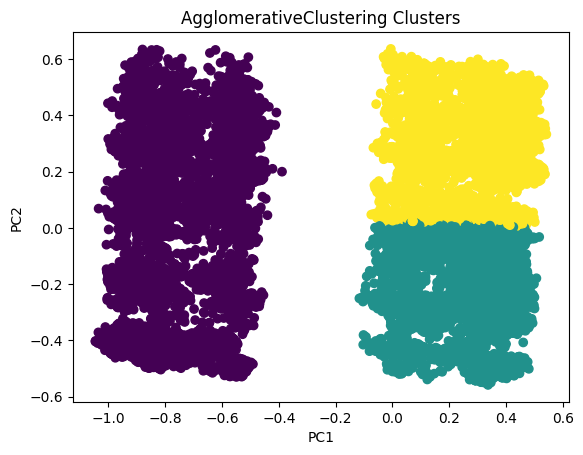

In [61]:
import matplotlib.pyplot as plt
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=X_pca["Agg-pca-cluster"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("AgglomerativeClustering Clusters")
plt.show()

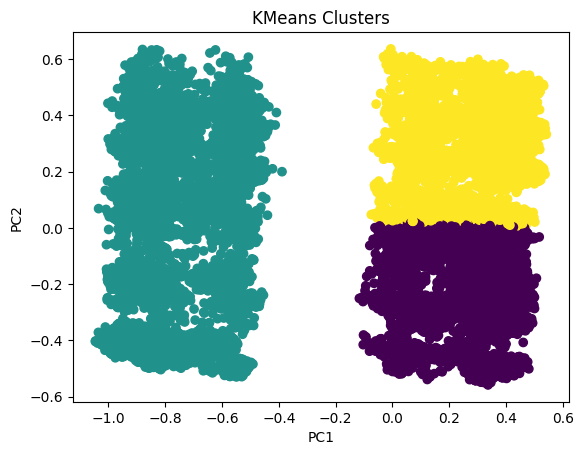

In [62]:
import matplotlib.pyplot as plt
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=X_pca["KNN-pca-cluster"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")
plt.show()

Cluster 0 points mostly on one side

Cluster 1 points in another region

Cluster 2 points are clearly separated and close to cluster 1

Both K-Means and Agglomerative clustering show similar separation patterns, as both achieved high silhouette scores.